<a href="https://colab.research.google.com/github/oyebimpeshittu/Multi-Channel-Marketing-Analysis/blob/main/Multi_channel_Marketing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Step 1: Data Loading, Preprocessing, and EDA

import python libraries and mount drive to load dataset

In [162]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

Load the Data: Import the `market_sales_data.csv` file into a pandas DataFrame.

In [164]:
market_data = pd.read_csv("/content/gdrive/MyDrive/AI_Projects/market_sales_data.csv")

In [165]:
print("\nFirst five rows of the dataset:")
market_data.head()


First five rows of the dataset:


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [166]:
market_data.shape

(572, 5)

In [167]:
print("\nSummary:")
market_data.describe()


Summary:


,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


Identify Variable Types:Observe the columns. `Radio`, `Social Media`, and `Sales` are numerical. However, `TV` (Low, Medium, High) and `Influencer` (Micro, Mega, Nano, Macro) are categorical.

In [168]:
print("\nDataset information:")
market_data.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


This dataset contains 572 rows and 5 columns. They are 3 float attributes and 2 object attributes.

Convert the categorical data to numbers (TV) using ordinal mapping because TV has a natural order (Low spend is less than Medium, which is less than High) ordinal mapping preserves this order in the numbers.

In [169]:
TV_map = {"Low": 1, "Medium": 2, "High": 3}
market_data["TV"] = market_data["TV"].map(TV_map)
print(market_data["TV"].value_counts())
print(market_data["TV"].dtype)

TV
2    205
1    201
3    166
Name: count, dtype: int64
int64


created a dictionary with Low=1, Medium=2, High=3 and applied it to the TV column.

In [170]:
market_data.head()

,TV,Radio,Social Media,Influencer,Sales
0,1,3.518070,2.293790,Micro,55.261284
1,1,7.756876,2.572287,Mega,67.574904
2,3,20.348988,1.227180,Micro,272.250108
3,2,20.108487,2.728374,Mega,195.102176
4,3,31.653200,7.776978,Nano,273.960377


##Step 2: Check for multicollinearity among independent variables (TV, Radio, Social Media) using correlation matrices and VIF

In [171]:
correlation_matrix = market_data[["TV", "Radio", "Social Media"]].corr()
print(correlation_matrix)

                    TV     Radio  Social Media
TV            1.000000  0.803377      0.511758
Radio         0.803377  1.000000      0.629941
Social Media  0.511758  0.629941      1.000000


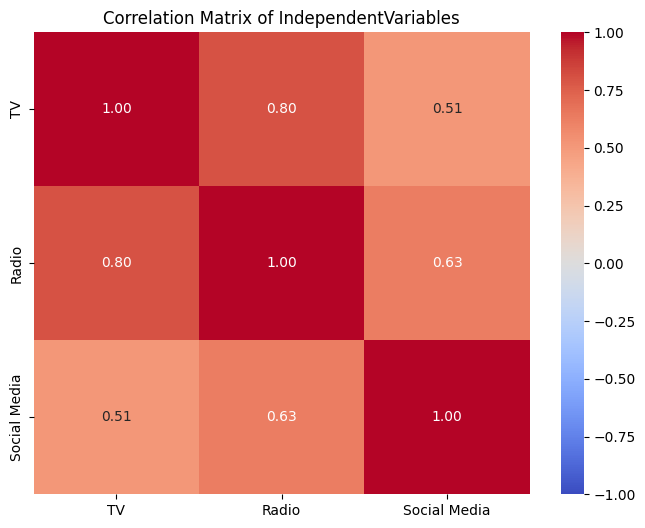

In [172]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of IndependentVariables")
plt.show()

In [173]:
X = market_data[["TV", "Radio", "Social Media"]]
X.head()

,TV,Radio,Social Media
0,1,3.518070,2.293790
1,1,7.756876,2.572287
2,3,20.348988,1.227180
3,2,20.108487,2.728374
4,3,31.653200,7.776978


In [174]:
Y = market_data["Sales"]
Y.head()

,Sales
0,55.261284
1,67.574904
2,272.250108
3,195.102176
4,273.960377


For VIF

In [175]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

        Feature        VIF
0            TV  13.015309
1         Radio  15.603724
2  Social Media   5.239052


This shows TV and Radio have VIF above 10. This means serious multicollinearity exists between them. Social Media VIF is 5.2, which is acceptable.

Remove Radio from the model because it has the highest VIF, and removing it will likely bring TV's VIF down to an acceptable range. Then recalculate VIF

In [176]:
X = market_data[["TV", "Social Media"]]
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

        Feature       VIF
0            TV  4.313146
1  Social Media  4.313146


Both VIF values dropped to 4.3, which is acceptable. Removing Radio fixed the multicollinearity problem.

##Step 3: Build a Multiple Linear Regression model using statsmodels to predict Sales

In [177]:
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
ols_data = market_data[["Sales", "TV", "Social Media"]]
ols_formula = "Sales ~ TV + Q('Social Media')"
Ols = ols(formula=ols_formula, data=ols_data)
model = Ols.fit()

##Step 4: Evaluate model performance using Adjusted R-squared and individual predictor p-values

In [178]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     2018.
Date:                Tue, 23 Jun 2026   Prob (F-statistic):          4.36e-259
Time:                        09:36:01   Log-Likelihood:                -2786.2
No. Observations:                 572   AIC:                             5578.
Df Residuals:                     569   BIC:                             5591.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           -16.0625      3.495     -4.596      0.000     -22.927      -9.198
TV                   99.8881      1.928     51.798      0.000      96.100     103.676
Q('Social Media')     3.5081      0.689      5.094      0.000       2.155       4.861
==============================================================================
Omnibus:                      314.484   Durbin-Watson:                   1.927
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               32.924
Skew:                          -0.014   Prob(JB):                     7.09e-08
Kurtosis:                       1.825   Cond. No.                         13.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Adjusted R-squared is 0.876. TV and Social Media explain 87.6% of the variation in Sales.
Both predictors have a p-value of 0.000, confirming they are statistically significant and should remain in the model.
Radio was removed earlier in Step 2 due to high VIF. The adjusted R-squared confirms the model is still strong without it.

##Step 5: Create diagnostic plots to validate Linearity, Normality, and Homoscedasticity of residuals

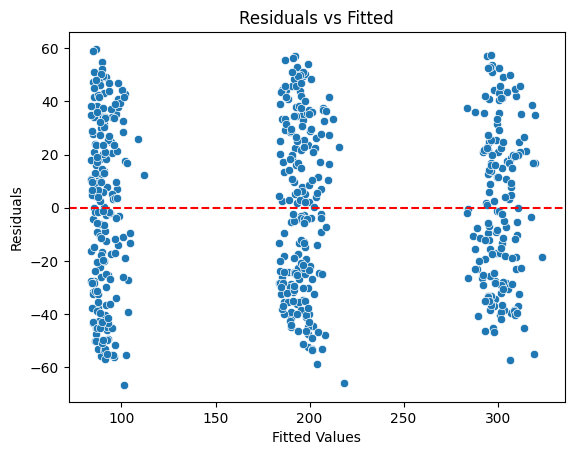

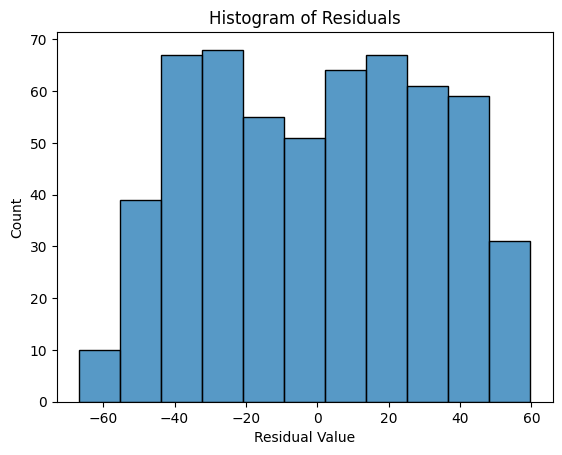

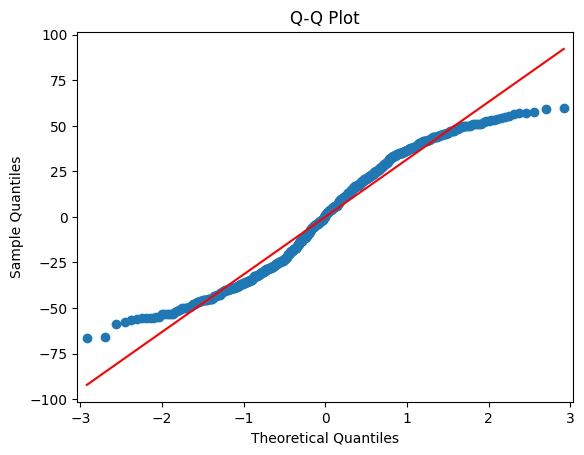

In [179]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Residuals
residuals = model.resid
fitted_values = model.fittedvalues

# Residuals vs Fitted
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Histogram of Residuals
sns.histplot(residuals)
plt.xlabel("Residual Value")
plt.title("Histogram of Residuals")
plt.show()

# Q-Q Plot
sm.qqplot(model.resid, line='s')
plt.title("Q-Q Plot")
plt.show()

Residuals vs Fitted: Residuals form three vertical bands due to TV being ordinal. Linearity assumption is acceptable.
Histogram of Residuals: Bell-shaped and centered near zero. Normality assumption is met.
Q-Q Plot: Points follow the line closely in the middle with slight deviation at the tails. Acceptable for this dataset size.
Model assumptions are sufficiently met.

In [180]:
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(model.resid, model.model.exog)
print("Breusch-Pagan p-value:", bp_test[1])

Breusch-Pagan p-value: 0.08029992822702892


Breusch-Pagan p-value is 0.08.
Above 0.05. Homoscedasticity assumption is met. No heteroscedasticity detected.

##Step 6: Interpret coefficients in context, explain the effect of a one-unit increase in one channel's spend while holding others constant

Intercept: -16.06. When TV and Social Media spend are both zero, Sales is -16.06. This is a baseline with no practical meaning.
TV: 99.89. Holding Social Media constant, each one unit increase in TV spend is associated with a 99.89 increase in Sales.
Social Media: 3.51. Holding TV constant, each one unit increase in Social Media spend is associated with a 3.51 increase in Sales.
TV has a much stronger effect on Sales than Social Media.

##Step 7: Synthesize findings into a clear, business-ready recommendation

TV is the strongest predictor of Sales with a coefficient of 99.89. Prioritize TV budget allocation.
Social Media has a smaller but statistically significant effect with a coefficient of 3.51. Maintain Social Media spend but do not increase it at the expense of TV.
Radio was removed due to multicollinearity. Its effect on Sales could not be isolated reliably from TV.
Recommendation: Allocate the majority of the marketing budget to TV. Use Social Media as a secondary channel.